In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tìm thư mục dự án từ vị trí chạy notebook.
ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "data" / "raw" / "dataset.csv").is_file()
    ),
    None
)

if ROOT is None:
    raise FileNotFoundError(
        "Không tìm thấy data/raw/dataset.csv. "
        "Hãy mở notebook từ bên trong thư mục dự án."
    )

DATA_PATH = ROOT / "data" / "raw" / "dataset.csv"
FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False
})

target_col = "deposit"

numerical_cols = [
    "age", "balance", "day", "duration",
    "campaign", "pdays", "previous"
]

categorical_cols = [
    "job", "marital", "education",
    "default", "housing", "loan",
    "contact", "month", "poutcome"
]

# Kiểm tra cấu trúc cơ bản.
expected_columns = numerical_cols + categorical_cols + [target_col]
assert set(df.columns) == set(expected_columns), "Tên cột không khớp."

assert df[target_col].notna().all(), "Biến mục tiêu có giá trị thiếu."
assert set(df[target_col].unique()) == {"no", "yes"}, "Nhãn không hợp lệ."

for col in numerical_cols:
    assert pd.api.types.is_numeric_dtype(df[col]), f"{col} không phải kiểu số."

# pdays chỉ được có mã -1 hoặc số ngày không âm.
assert df["pdays"].dropna().ge(-1).all(), "Có pdays nhỏ hơn -1 cần kiểm tra."

print(f"Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Đặc trưng số: {len(numerical_cols)}")
print(f"Đặc trưng phân loại: {len(categorical_cols)}")
print(f"Tổng giá trị thiếu (NaN): {df.isna().sum().sum()}")
print(f"Số dòng trùng hoàn toàn: {df.duplicated().sum()}")

display(df.head())
display(df.dtypes.to_frame("dtype"))

Kích thước: 11,162 dòng × 17 cột
Đặc trưng số: 7
Đặc trưng phân loại: 9
Tổng giá trị thiếu (NaN): 0
Số dòng trùng hoàn toàn: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


,dtype
age,int64
job,str
marital,str
education,str
default,str
balance,int64
housing,str
loan,str
contact,str
day,int64


,count,percentage
deposit,,
no,5873,52.62
yes,5289,47.38


Tỷ số lớp đông / lớp ít: 1.110:1
Chênh lệch số mẫu: 584
Chênh lệch tỷ lệ: 5.23 điểm phần trăm


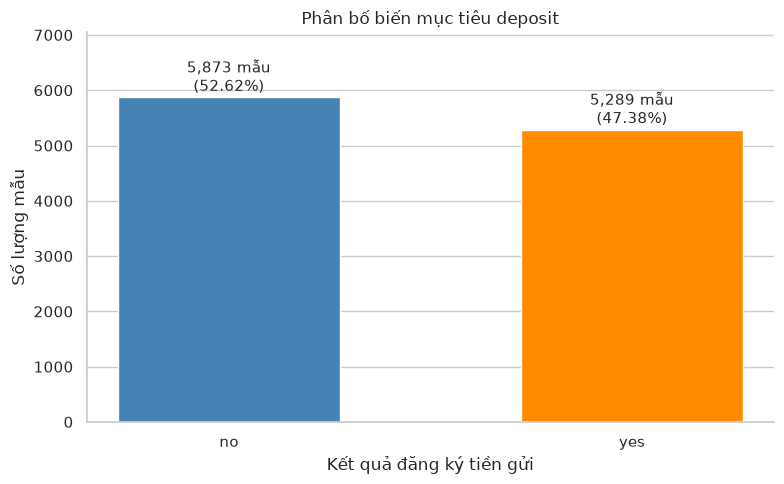

In [2]:
target_counts = (
    df[target_col]
    .value_counts()
    .reindex(["no", "yes"])
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_counts / target_counts.sum() * 100
})

imbalance_ratio = target_counts.max() / target_counts.min()

percentage_gap = (
    target_summary["percentage"].max()
    - target_summary["percentage"].min()
)

display(target_summary.round(2))

print(f"Tỷ số lớp đông / lớp ít: {imbalance_ratio:.3f}:1")
print(f"Chênh lệch số mẫu: {target_counts.max() - target_counts.min():,}")
print(f"Chênh lệch tỷ lệ: {percentage_gap:.2f} điểm phần trăm")

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=["steelblue", "darkorange"],
    width=0.55
)

for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + target_counts.max() * 0.02,
        f"{count:,} mẫu\n({count / len(df):.2%})",
        ha="center",
        fontsize=11
    )

ax.set_title("Phân bố biến mục tiêu deposit")
ax.set_xlabel("Kết quả đăng ký tiền gửi")
ax.set_ylabel("Số lượng mẫu")
ax.set_ylim(0, target_counts.max() * 1.2)
ax.grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "02_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Nhận xét phân bố biến mục tiêu

Lớp `no` có 5.873 mẫu (52,62%), lớp `yes` có 5.289 mẫu (47,38%).
Chênh lệch là 584 mẫu, tương ứng 5,23 điểm phần trăm tính từ tỷ lệ
chưa làm tròn. Tỷ số lớp đông trên lớp ít khoảng 1,110:1.

Như vậy, biến mục tiêu tương đối cân bằng, không có mất cân bằng
nhãn nghiêm trọng trong tập dữ liệu này.

Tỷ lệ trên chỉ mô tả bộ dữ liệu đang khảo sát; chưa thể suy rộng
thành tỷ lệ đăng ký thực tế của toàn bộ khách hàng ngân hàng.

In [3]:
# Thống kê trạng thái pdays trên toàn bộ dữ liệu.
pdays_status_counts = pd.Series({
    "Chưa từng liên hệ (-1)": df["pdays"].eq(-1).sum(),
    "Đã từng liên hệ (>= 0)": df["pdays"].ge(0).sum(),
    "Thiếu dữ liệu (NaN)": df["pdays"].isna().sum()
})

pdays_status_summary = pd.DataFrame({
    "count": pdays_status_counts,
    "percentage": pdays_status_counts / len(df) * 100
})

print("Trạng thái pdays — tỷ lệ tính trên toàn bộ dữ liệu:")
display(pdays_status_summary.round(2))

# Bản sao phục vụ thống kê; không sửa df gốc.
numeric_data = df[numerical_cols].copy()

numeric_data["pdays"] = numeric_data["pdays"].where(
    numeric_data["pdays"].ge(0)
)

# describe() và skew() tự bỏ qua NaN.
numerical_summary = numeric_data.describe().T
numerical_summary["skewness"] = numeric_data.skew()

# Đổi nhãn hàng để tránh nhầm phạm vi thống kê.
numerical_summary = numerical_summary.rename(
    index={"pdays": "pdays (>= 0; đã liên hệ)"}
)

print("Thống kê các đặc trưng số:")
display(numerical_summary.round(3))

print(
    "Lưu ý: count của pdays chỉ đếm số bản ghi có số ngày hợp lệ; "
    "không phải tổng số bản ghi của bộ dữ liệu."
)

Trạng thái pdays — tỷ lệ tính trên toàn bộ dữ liệu:


,count,percentage
Chưa từng liên hệ (-1),8324,74.57
Đã từng liên hệ (>= 0),2838,25.43
Thiếu dữ liệu (NaN),0,0.00


Thống kê các đặc trưng số:


,count,mean,std,min,25%,50%,75%,max,skewness
age,11162.0,41.232,11.913,18.0,32.0,39.0,49.0,95.0,0.863
balance,11162.0,1528.539,3225.413,-6847.0,122.0,550.0,1708.0,81204.0,8.225
day,11162.0,15.658,8.421,1.0,8.0,15.0,22.0,31.0,0.111
duration,11162.0,371.994,347.128,2.0,138.0,255.0,496.0,3881.0,2.144
campaign,11162.0,2.508,2.722,1.0,1.0,2.0,3.0,63.0,5.546
pdays (>= 0; đã liên hệ),2838.0,204.818,122.197,1.0,98.0,182.0,286.0,854.0,1.275
previous,11162.0,0.833,2.292,0.0,0.0,0.0,1.0,58.0,7.335


Lưu ý: count của pdays chỉ đếm số bản ghi có số ngày hợp lệ; không phải tổng số bản ghi của bộ dữ liệu.


### Cách diễn giải thống kê

- `count`: số giá trị được sử dụng để tính thống kê.
- `mean`: trung bình cộng.
- `std`: độ lệch chuẩn mẫu.
- `25%`, `50%`, `75%`: Q1, trung vị và Q3.
- `skewness`: độ bất đối xứng của phân bố.

Quy ước mô tả tham khảo:
- |skewness| < 0,5: gần đối xứng.
- 0,5 ≤ |skewness| ≤ 1: lệch vừa.
- |skewness| > 1: lệch mạnh.

Skewness dương biểu thị lệch phải; skewness âm biểu thị lệch trái.
Skewness gần 0 không chứng minh phân bố chuẩn.

Riêng `pdays`, bảng chỉ sử dụng 2.838 bản ghi có giá trị >= 0.
Các mã -1 vẫn được giữ trong dữ liệu gốc và thống kê riêng theo trạng thái.

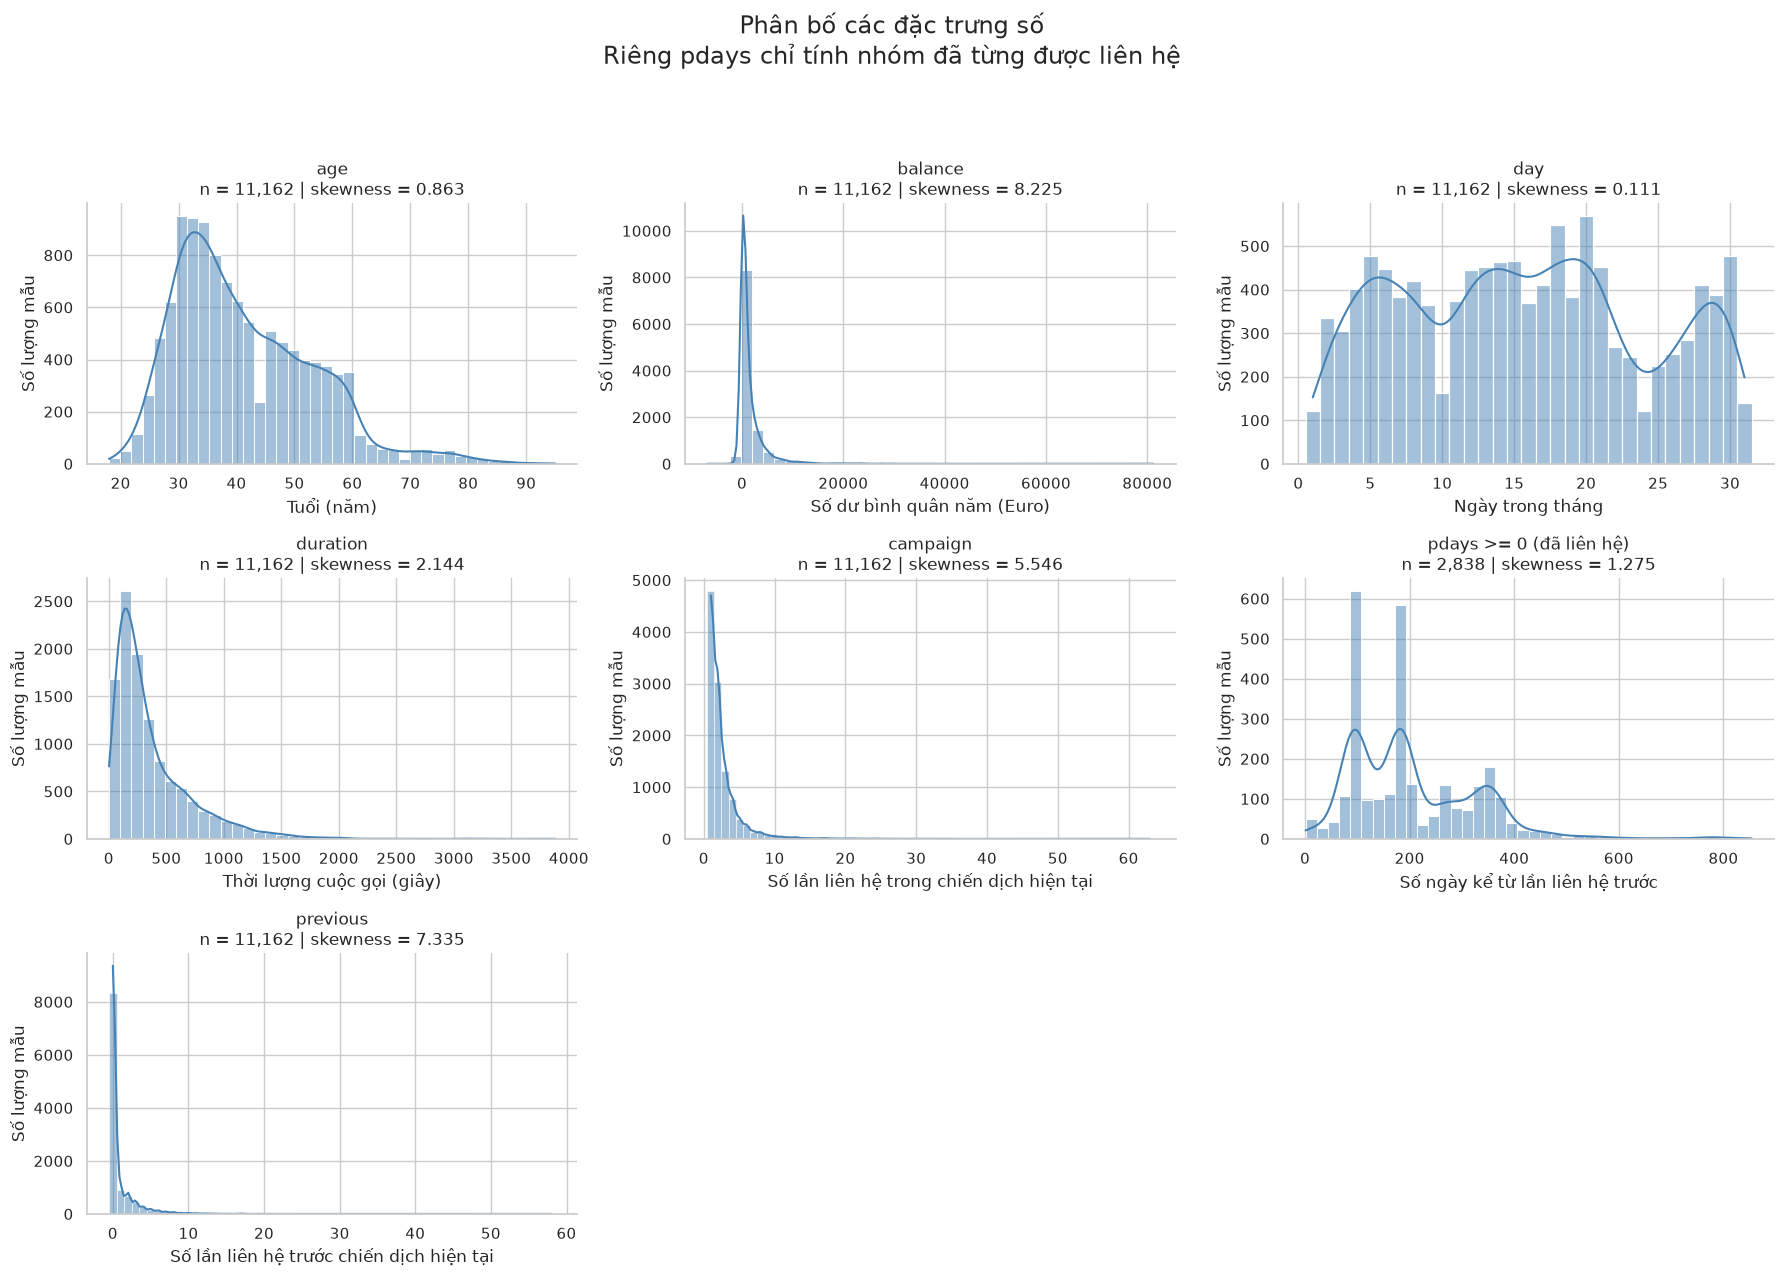

In [4]:
axis_labels = {
    "age": "Tuổi (năm)",
    "balance": "Số dư bình quân năm (Euro)",
    "day": "Ngày trong tháng",
    "duration": "Thời lượng cuộc gọi (giây)",
    "campaign": "Số lần liên hệ trong chiến dịch hiện tại",
    "pdays": "Số ngày kể từ lần liên hệ trước",
    "previous": "Số lần liên hệ trước chiến dịch hiện tại"
}

integer_bins_cols = {"day", "campaign", "previous"}

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    values = numeric_data[col].dropna()

    # Mỗi số nguyên có một bin riêng cho các biến này.
    if col in integer_bins_cols:
        bins = np.arange(
            values.min() - 0.5,
            values.max() + 1.5,
            1
        )
    else:
        bins = 40

    sns.histplot(
        x=values,
        bins=bins,
        kde=True,
        kde_kws={"cut": 0},
        color="steelblue",
        ax=ax
    )

    label = "pdays >= 0 (đã liên hệ)" if col == "pdays" else col

    ax.set_title(
        f"{label}\nn = {len(values):,} | skewness = {values.skew():.3f}"
    )
    ax.set_xlabel(axis_labels[col])
    ax.set_ylabel("Số lượng mẫu")

# Ẩn hai ô không sử dụng.
for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

fig.suptitle(
    "Phân bố các đặc trưng số\n"
    "Riêng pdays chỉ tính nhóm đã từng được liên hệ",
    fontsize=17
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(
    FIGURE_DIR / "04_feature_histograms.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Nhận xét phân bố các đặc trưng số

- `age` lệch phải vừa, với skewness khoảng 0,863. Trung vị là 39 tuổi,
  Q1 và Q3 lần lượt là 32 và 49 tuổi.
- `balance` lệch phải rất mạnh, với skewness khoảng 8,225.
  Trung bình 1.528,54 Euro cao hơn đáng kể trung vị 550 Euro.
  Dữ liệu có số dư âm và một số số dư lớn, lên tới 81.204 Euro.
- `duration` lệch phải mạnh, với skewness khoảng 2,144.
  Trung vị là 255 giây, trung bình khoảng 371,99 giây.
- `campaign` và `previous` lệch phải mạnh, với skewness lần lượt
  khoảng 5,546 và 7,335. Phần lớn quan sát có số lần liên hệ thấp,
  trong khi một số bản ghi có số lần liên hệ rất cao.
- `day` có skewness khoảng 0,111, cho thấy ít bất đối xứng.
  Tuy nhiên, đây là biến ngày trong tháng, có miền rời rạc 1–31;
  không thể kết luận phân bố chuẩn chỉ từ skewness nhỏ.
- `pdays` trên nhóm đã được liên hệ có skewness khoảng 1,275,
  cho thấy lệch phải.

Histogram và KDE dùng để khảo sát hình dạng phân bố.
KDE chỉ là đường làm trơn hỗ trợ quan sát, đặc biệt cần thận trọng
khi diễn giải các biến rời rạc.

Không tự động coi giá trị lớn hoặc số dư âm là lỗi dữ liệu.

In [7]:
categorical_data = (
    df[categorical_cols]
    .astype("string")
    .fillna("<missing>")
)

cardinality = categorical_data.nunique().rename("cardinality")

print("Số nhãn khác nhau của từng đặc trưng:")
display(cardinality.to_frame())

categorical_tables = {}

for col in categorical_cols:
    category_counts = categorical_data[col].value_counts()

    category_summary = pd.DataFrame({
        "count": category_counts,
        "percentage": category_counts / len(df) * 100
    })

    categorical_tables[col] = category_summary

    print(f"\nĐặc trưng: {col}")
    display(category_summary.round(2))

Số nhãn khác nhau của từng đặc trưng:


,cardinality
job,12
marital,3
education,4
default,2
housing,2
loan,2
contact,3
month,12
poutcome,4



Đặc trưng: job


,count,percentage
job,,
management,2566,22.99
blue-collar,1944,17.42
technician,1823,16.33
admin.,1334,11.95
services,923,8.27
retired,778,6.97
self-employed,405,3.63
student,360,3.23
unemployed,357,3.2



Đặc trưng: marital


...

,count,percentage
contact,,
cellular,8042,72.05
unknown,2346,21.02
telephone,774,6.93



Đặc trưng: month


,count,percentage
month,,
may,2824,25.3
aug,1519,13.61
jul,1514,13.56
jun,1222,10.95
nov,943,8.45
apr,923,8.27
feb,776,6.95
oct,392,3.51
jan,344,3.08



Đặc trưng: poutcome


,count,percentage
poutcome,,
unknown,8326,74.59
failure,1228,11.0
success,1071,9.6
other,537,4.81


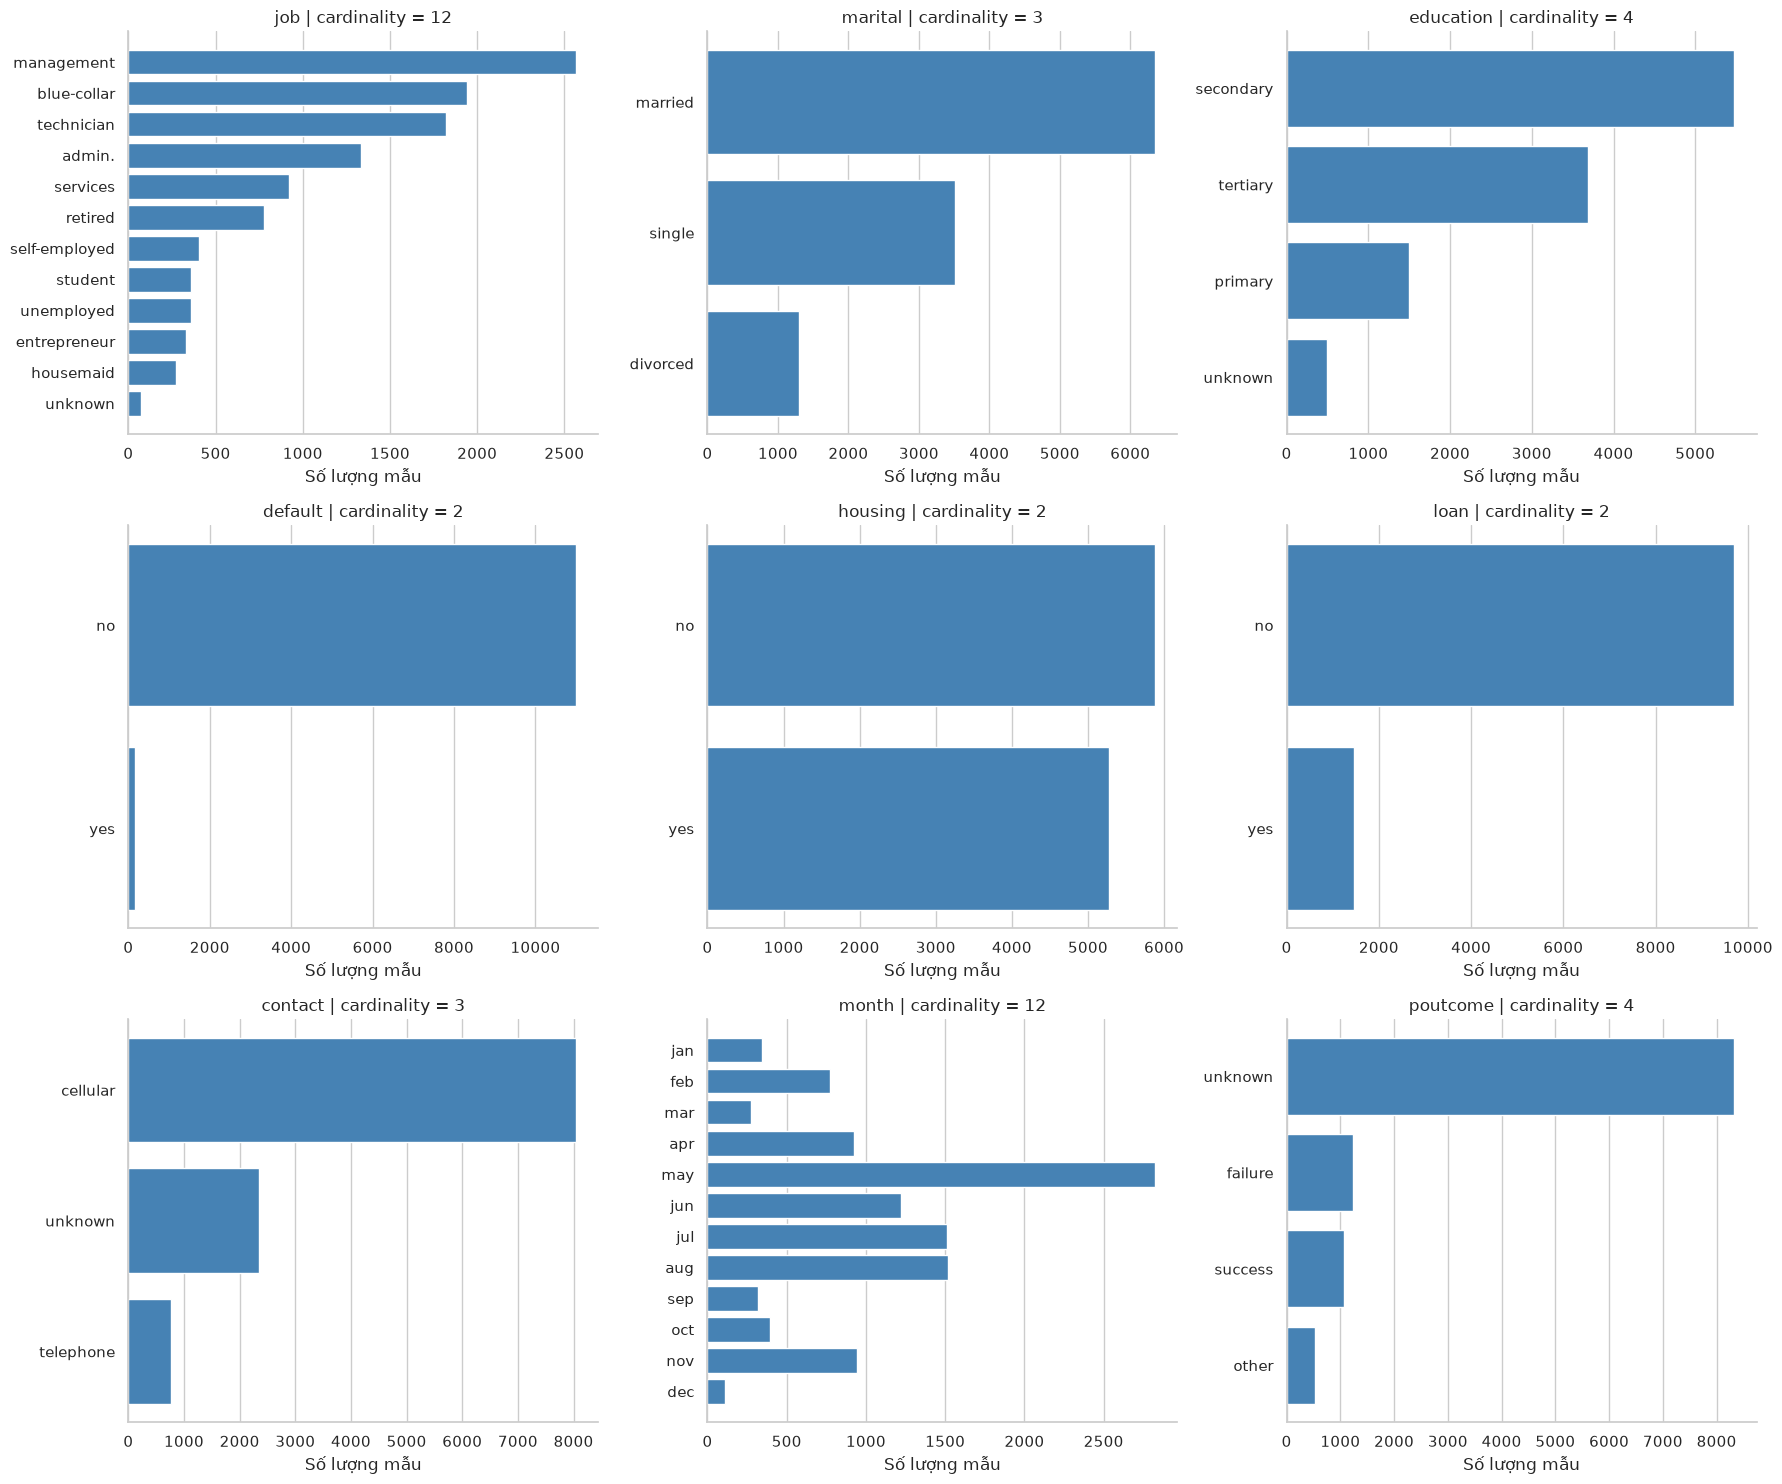

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

for ax, col in zip(axes.flatten(), categorical_cols):
    counts = categorical_tables[col]["count"]

    if col == "month":
        counts = counts.reindex(month_order, fill_value=0)

    ax.barh(counts.index, counts.values, color="steelblue")
    ax.invert_yaxis()

    ax.set_title(f"{col} | cardinality = {cardinality[col]}")
    ax.set_xlabel("Số lượng mẫu")
    ax.set_ylabel("")
    ax.grid(axis="y", visible=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "05_categorical_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Nhận xét phân bố các đặc trưng phân loại

- Cardinality dao động từ 2 đến 12. `job` và `month` có 12 nhãn;
  `default`, `housing`, `loan` có 2 nhãn.
- `job` phổ biến nhất là `management` với 2.566 mẫu (22,99%).
- `marital` chủ yếu là `married` với 6.351 mẫu (56,90%).
- `education` phổ biến nhất là `secondary` với 5.476 mẫu (49,06%).
- `default` tập trung mạnh ở `no` (98,49%); `yes` chỉ chiếm 1,51%.
- `loan` chủ yếu là `no` (86,92%), trong khi `housing` tương đối cân bằng:
  `no` chiếm 52,69% và `yes` chiếm 47,31%.
- `contact` chủ yếu là `cellular` (72,05%), nhưng `unknown`
  vẫn chiếm 21,02%.
- `month` xuất hiện nhiều nhất là `may` (25,30%).
- `poutcome` có tỷ lệ `unknown` cao, khoảng 74,59%.
  Ngoài ra, `education` và `job` cũng có nhãn `unknown`,
  lần lượt khoảng 4,45% và 0,63%.

Sự chênh lệch giữa các nhãn của đặc trưng đầu vào không phải
mất cân bằng của biến mục tiêu `deposit`.

Các kết quả trên chỉ mô tả thành phần dữ liệu, chưa cho biết
nghề nghiệp, tháng liên hệ hoặc nhóm khách hàng nào có khả năng
đăng ký tiền gửi cao hơn.

## 2.2. Khám phá và trực quan hóa phân bố đơn biến

Phân tích đơn biến được thực hiện nhằm mô tả phân bố của biến mục tiêu và từng đặc trưng đầu vào trong bộ dữ liệu gồm 11.162 bản ghi. Các phương pháp sử dụng bao gồm thống kê tần suất, tỷ lệ phần trăm, thống kê mô tả, histogram kết hợp đường ước lượng mật độ KDE và biểu đồ thanh. Dữ liệu gốc được giữ nguyên trong quá trình khảo sát.

### 2.2.1. Phân bố biến mục tiêu

Biến mục tiêu `deposit` gồm hai lớp: `no` — khách hàng không đăng ký tiền gửi có kỳ hạn và `yes` — khách hàng đăng ký tiền gửi có kỳ hạn.

| Nhãn     | Số lượng mẫu |       Tỷ lệ |
| -------- | -----------: | ----------: |
| `no`     |        5.873 |      52,62% |
| `yes`    |        5.289 |      47,38% |
| **Tổng** |   **11.162** | **100,00%** |

Hai lớp chênh lệch 584 mẫu, tương ứng khoảng 5,23 điểm phần trăm tính từ tỷ lệ chưa làm tròn. Tỷ số giữa lớp đông và lớp ít khoảng 1,110:1. Như vậy, biến mục tiêu tương đối cân bằng, không xuất hiện mất cân bằng nhãn nghiêm trọng trong tập dữ liệu đang khảo sát.

Tỷ lệ trên phản ánh thành phần của bộ dữ liệu được cung cấp, chưa thể suy rộng thành tỷ lệ đăng ký tiền gửi của toàn bộ khách hàng ngân hàng.

*Chèn hình `02_target_distribution.png` — Phân bố biến mục tiêu `deposit`.*

### 2.2.2. Phân bố các đặc trưng số

Bảy đặc trưng số được khảo sát gồm `age`, `balance`, `day`, `duration`, `campaign`, `pdays` và `previous`. Bảng dưới trình bày một số chỉ số thống kê chính.

| Đặc trưng                 | Số mẫu sử dụng | Trung bình | Trung vị | Skewness |
| ------------------------- | -------------: | ---------: | -------: | -------: |
| `age`                     |         11.162 |     41,232 |       39 |    0,863 |
| `balance`                 |         11.162 |  1.528,539 |      550 |    8,225 |
| `day`                     |         11.162 |     15,658 |       15 |    0,111 |
| `duration`                |         11.162 |    371,994 |      255 |    2,144 |
| `campaign`                |         11.162 |      2,508 |        2 |    5,546 |
| `pdays` — chỉ giá trị ≥ 0 |          2.838 |    204,818 |      182 |    1,275 |
| `previous`                |         11.162 |      0,833 |        0 |    7,335 |

**Độ tuổi (`age`).** Tuổi khách hàng nằm trong khoảng 18–95 tuổi, có trung vị 39 tuổi và trung bình 41,232 tuổi. Phân vị thứ nhất và thứ ba lần lượt là 32 và 49 tuổi. Skewness bằng 0,863 cho thấy phân bố lệch phải vừa, với đuôi kéo dài về phía các độ tuổi cao.

**Số dư tài khoản (`balance`).** Phân bố lệch phải rất mạnh, với skewness 8,225. Trung bình 1.528,539 Euro cao hơn đáng kể trung vị 550 Euro; Q1 và Q3 lần lượt là 122 và 1.708 Euro. Giá trị lớn nhất đạt 81.204 Euro, cho thấy một số số dư lớn nằm xa phần trung tâm của dữ liệu. Cột này cũng có giá trị âm, nhỏ nhất −6.847 Euro. Các giá trị âm và cực đoan được giữ lại khi khảo sát, không tự động coi là lỗi dữ liệu chỉ dựa vào dấu hoặc độ lớn.

**Ngày liên hệ (`day`).** Giá trị nằm trong khoảng 1–31, có trung vị 15 và skewness 0,111. Chỉ số này cho thấy mức bất đối xứng thấp, nhưng không đủ để kết luận phân bố chuẩn. Do `day` là biến số nguyên rời rạc, histogram sử dụng các khoảng có biên khớp với từng ngày để phản ánh đúng tần suất.

**Thời lượng cuộc gọi (`duration`).** Trung vị là 255 giây, trong khi trung bình khoảng 371,994 giây. Giá trị lớn nhất đạt 3.881 giây và skewness bằng 2,144. Kết quả cho thấy phân bố lệch phải mạnh, với một số cuộc gọi dài kéo trung bình lên.

**Số lần liên hệ (`campaign`, `previous`).** Cả hai biến đều lệch phải mạnh, với skewness lần lượt là 5,546 và 7,335. `campaign` có trung vị 2 lần, Q3 bằng 3 lần và cực đại 63 lần. `previous` có trung vị 0, Q3 bằng 1 lần và cực đại 58 lần. Như vậy, các quan sát tập trung ở số lần liên hệ thấp, trong khi một số bản ghi có số lần liên hệ cao tạo thành đuôi phải dài.

**Số ngày kể từ lần liên hệ trước (`pdays`).** Giá trị −1 là mã biểu thị chưa từng được liên hệ trước đó, không phải khoảng thời gian thực. Có 8.324 bản ghi (74,57%) mang mã này và 2.838 bản ghi (25,43%) có số ngày hợp lệ. Vì vậy, nhóm thống kê riêng trạng thái liên hệ và chỉ sử dụng các giá trị `pdays ≥ 0` để tính thống kê thời gian và vẽ histogram.

Trong nhóm có số ngày hợp lệ, trung bình là 204,818 ngày, trung vị 182 ngày, Q1 bằng 98 ngày và Q3 bằng 286 ngày. Giá trị nhỏ nhất là 1 ngày, lớn nhất là 854 ngày; skewness 1,275 cho thấy phân bố lệch phải. Các chỉ số này chỉ mô tả nhóm đã từng được liên hệ. Số mẫu 2.838 trong bảng là số bản ghi dùng để phân tích thời gian, không có nghĩa dữ liệu gốc bị thiếu 8.324 giá trị.

Nhìn chung, phần lớn các đặc trưng số có phân bố lệch phải. `day` có độ bất đối xứng thấp, nhưng chưa có cơ sở khẳng định đặc trưng nào tuân theo phân bố chuẩn chỉ từ histogram, KDE và skewness. Đường KDE được sử dụng để hỗ trợ quan sát hình dạng, cần diễn giải thận trọng đối với các biến rời rạc.

*Chèn hình `04_feature_histograms.png` — Histogram và KDE của các đặc trưng số; riêng `pdays` chỉ sử dụng nhóm đã từng được liên hệ.*

### 2.2.3. Phân bố các đặc trưng phân loại

Chín đặc trưng phân loại được khảo sát bằng số lượng nhãn khác nhau (cardinality), bảng tần suất và biểu đồ thanh. Các nhãn `unknown` được giữ nguyên để thể hiện đầy đủ thành phần dữ liệu.

| Đặc trưng   | Cardinality | Nhãn phổ biến nhất | Số mẫu |  Tỷ lệ |
| ----------- | ----------: | ------------------ | -----: | -----: |
| `job`       |          12 | `management`       |  2.566 | 22,99% |
| `marital`   |           3 | `married`          |  6.351 | 56,90% |
| `education` |           4 | `secondary`        |  5.476 | 49,06% |
| `default`   |           2 | `no`               | 10.994 | 98,49% |
| `housing`   |           2 | `no`               |  5.881 | 52,69% |
| `loan`      |           2 | `no`               |  9.702 | 86,92% |
| `contact`   |           3 | `cellular`         |  8.042 | 72,05% |
| `month`     |          12 | `may`              |  2.824 | 25,30% |
| `poutcome`  |           4 | `unknown`          |  8.326 | 74,59% |

Cardinality dao động từ 2 đến 12. `job` và `month` có nhiều nhãn nhất, trong khi `default`, `housing` và `loan` là các biến hai nhãn. Nghề nghiệp xuất hiện nhiều nhất là `management`, nhưng chỉ chiếm 22,99%, cho thấy dữ liệu phân bố trên nhiều nhóm nghề. `marital` chủ yếu là `married` (56,90%), còn `education` phổ biến nhất là `secondary` (49,06%).

Phân bố của `default` tập trung mạnh ở nhãn `no` (98,49%), trong khi `yes` chỉ có 168 mẫu (1,51%). `loan` cũng thiên về `no` (86,92%). Ngược lại, `housing` tương đối cân bằng, với `no` chiếm 52,69% và `yes` chiếm 47,31%. Sự chênh lệch trong các đặc trưng đầu vào này cần được phân biệt với mất cân bằng nhãn của biến mục tiêu `deposit`.

Đối với thông tin liên hệ, `cellular` chiếm 72,05% ở cột `contact`, còn `unknown` chiếm 21,02%. Tháng xuất hiện nhiều nhất là `may` (25,30%). Những tỷ lệ này phản ánh mức xuất hiện trong tập dữ liệu, chưa đủ để kết luận phương thức hoặc tháng liên hệ nào mang lại hiệu quả tiếp thị cao hơn.

Đáng chú ý, `poutcome` có 74,59% nhãn `unknown`, cho thấy phần lớn bản ghi không có kết quả chiến dịch trước được xác định trong cột này. `education` và `job` cũng có nhãn `unknown`, lần lượt chiếm 4,45% và 0,63%. Các nhãn này được giữ rõ trong phân tích để lưu ý khi lựa chọn cách tiền xử lý ở giai đoạn tiếp theo.

*Chèn hình `05_categorical_distributions.png` — Phân bố tần suất của các đặc trưng phân loại.*
